In [1]:
# LOADING OF DATASET
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("rna_seq_experiments_data.csv")

# Preview
df.head()

,experiment_id,sample_id,sample_storage_days,rin_score,reagent_age_days,calibration_gap_days,room_temp_variance,operator_experience_years,previous_operator_failure_rate,run_duration_minutes,contamination_flag,outcome
0,1,SMP001,12,5.99,50,50,1.49,6.4,0.078,100,0,0
1,2,SMP002,3,8.09,53,44,3.79,7.1,0.263,93,0,0
2,3,SMP003,14,7.36,4,76,0.74,8.3,0.219,89,0,1
3,4,SMP004,19,6.64,47,78,4.40,3.5,0.189,84,0,1
4,5,SMP005,13,6.25,59,11,3.23,1.0,0.073,133,0,1


In [2]:
# BASIC DATA CHECK
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   experiment_id                   300 non-null    int64  
 1   sample_id                       300 non-null    object 
 2   sample_storage_days             300 non-null    int64  
 3   rin_score                       300 non-null    float64
 4   reagent_age_days                300 non-null    int64  
 5   calibration_gap_days            300 non-null    int64  
 6   room_temp_variance              300 non-null    float64
 7   operator_experience_years       300 non-null    float64
 8   previous_operator_failure_rate  300 non-null    float64
 9   run_duration_minutes            300 non-null    int64  
 10  contamination_flag              300 non-null    int64  
 11  outcome                         300 non-null    int64  
dtypes: float64(4), int64(7), object(1)
m

,experiment_id,sample_storage_days,rin_score,reagent_age_days,calibration_gap_days,room_temp_variance,operator_experience_years,previous_operator_failure_rate,run_duration_minutes,contamination_flag,outcome
count,300.000000,300.000000,300.000000,300.0000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,16.163333,7.382800,31.7500,48.470000,2.597167,5.690333,0.156273,110.990000,0.160000,0.740000
std,86.746758,8.642471,1.462394,17.7574,27.061477,1.128657,2.847296,0.088398,17.829269,0.367219,0.439367
min,1.000000,1.000000,5.020000,1.0000,1.000000,0.550000,0.500000,0.010000,80.000000,0.000000,0.000000
25%,75.750000,9.000000,6.107500,16.0000,25.750000,1.680000,3.300000,0.078000,95.000000,0.000000,0.000000
50%,150.500000,17.000000,7.385000,33.0000,49.000000,2.695000,5.850000,0.150000,111.000000,0.000000,1.000000
75%,225.250000,23.250000,8.640000,47.0000,73.000000,3.540000,8.200000,0.232000,127.000000,0.000000,1.000000
max,300.000000,30.000000,9.970000,60.0000,90.000000,4.500000,10.500000,0.309000,139.000000,1.000000,1.000000


In [3]:
# PREPARE FEATURES & TARGET
X = df.drop(columns=["experiment_id", "sample_id", "outcome"])
y = df["outcome"]

In [4]:
# TRAIN/TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# TRAIN RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
# PREDICTIONS
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [7]:
# EVALUATION METRICS
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("ROC-AUC:", roc_auc)

Accuracy: 0.6166666666666667
Recall: 0.9024390243902439
Precision: 0.6607142857142857
ROC-AUC: 0.5044929396662388


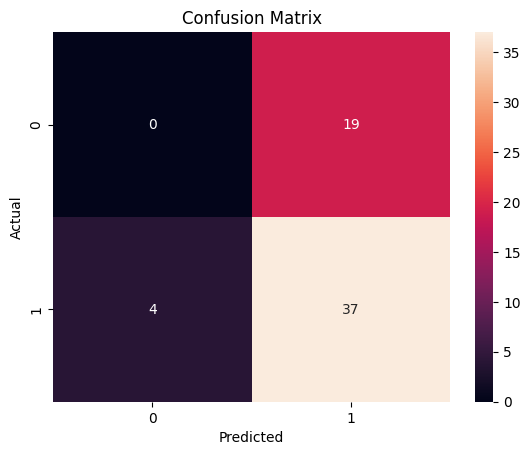

In [8]:
# VISUALIZATION OF CONFUSION MMATRIX
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

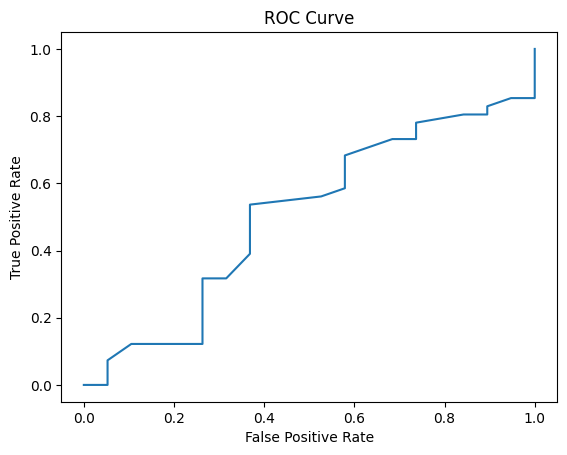

In [9]:
# vISUALIZATION OF ROC-CURVE
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

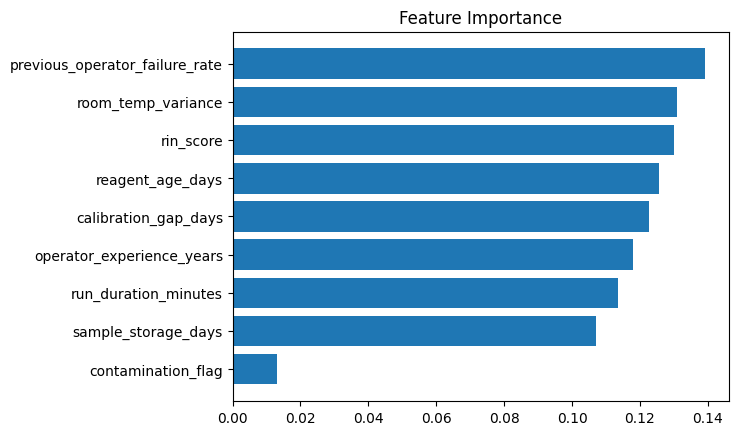

In [15]:
# FEATURE IMPORTANCE
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

# VISUALIZATION
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [11]:
# CONVERT MODEL PROBABILITIES INTO A 0–100 RISK SCORE (HIGHER = HIGHER FAILURE RISK)

# Failure probability = 1 - success probability
failure_prob = 1 - y_prob

# Convert to percentage scale
risk_score = failure_prob * 100

# Add to test dataset
results_df = X_test.copy()
results_df["Actual Outcome"] = y_test.values
results_df["Predicted Outcome"] = y_pred
results_df["Risk Score (%)"] = risk_score

results_df.head()

,sample_storage_days,rin_score,reagent_age_days,calibration_gap_days,room_temp_variance,operator_experience_years,previous_operator_failure_rate,run_duration_minutes,contamination_flag,Actual Outcome,Predicted Outcome,Risk Score (%)
203,7,9.63,60,17,4.20,1.3,0.204,138,1,1,1,23.0
266,28,9.77,59,4,1.58,2.8,0.104,133,0,1,1,29.0
152,12,5.59,24,55,3.95,5.4,0.268,130,0,1,1,38.0
9,22,5.17,3,10,2.13,7.7,0.125,125,0,1,1,22.0
233,13,7.21,56,27,3.27,6.4,0.265,109,1,1,1,28.0


In [12]:
# CLASSIFY EXPERIMENTS INTO LOW, MODERATE AND HIGH RISK CATEGORIES

def categorize_risk(score):
    if score < 30:
        return "Low Risk"
    elif score < 60:
        return "Moderate Risk"
    else:
        return "High Risk"

results_df["Risk Category"] = results_df["Risk Score (%)"].apply(categorize_risk)

results_df.head()

,sample_storage_days,rin_score,reagent_age_days,calibration_gap_days,room_temp_variance,operator_experience_years,previous_operator_failure_rate,run_duration_minutes,contamination_flag,Actual Outcome,Predicted Outcome,Risk Score (%),Risk Category
203,7,9.63,60,17,4.20,1.3,0.204,138,1,1,1,23.0,Low Risk
266,28,9.77,59,4,1.58,2.8,0.104,133,0,1,1,29.0,Low Risk
152,12,5.59,24,55,3.95,5.4,0.268,130,0,1,1,38.0,Moderate Risk
9,22,5.17,3,10,2.13,7.7,0.125,125,0,1,1,22.0,Low Risk
233,13,7.21,56,27,3.27,6.4,0.265,109,1,1,1,28.0,Low Risk


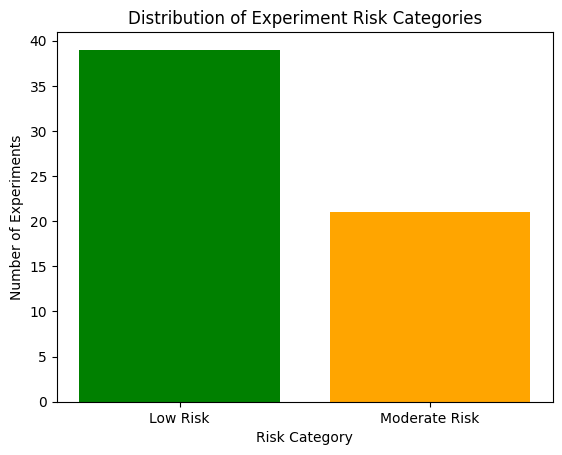

In [13]:
# VISUALIZE DISTRIBUTION OF RISK CATEGORIES WITH COLOR-CODED BARS
# (GREEN = LOW RISK, ORANGE = MODERATE RISK, RED = HIGH RISK)

import matplotlib.pyplot as plt

# Count risk categories
risk_counts = results_df["Risk Category"].value_counts()

# Ensure consistent order
risk_counts = risk_counts.reindex(["Low Risk", "Moderate Risk", "High Risk"])

# Define colors for each category
colors = ["green", "orange", "red"]

# Plot
plt.figure()
plt.bar(risk_counts.index, risk_counts.values, color=colors)

plt.title("Distribution of Experiment Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Experiments")

plt.show()

In [14]:
# EXPORT MODEL PREDICTIONS AND RISK SCORES TO CSV FILE

results_df.to_csv("rna_seq_risk_predictions.csv", index=False)